In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

np.random.seed(42)
n = 1000

# Tạo dataset gốc
data = pd.DataFrame({
    "Age": np.random.randint(20, 70, n),
    "Education": np.random.randint(10, 20, n),
    "Income": np.random.normal(5000, 1500, n),
    "Experience": np.random.randint(0, 40, n)
})

# Tạo correlation Income-Age để KNN có thể học
data["Income"] = 3000 + 50 * data["Age"] + np.random.normal(0, 500, n)

data_missing = data.copy()

# ============ Cơ chế 1: MCAR cho Age ============
p_mcar = 0.15
mask_mcar = np.random.rand(n) < p_mcar
data_missing.loc[mask_mcar, "Age"] = np.nan

# ============ Cơ chế 2: MAR cho Education (phụ thuộc Age) ============
logit_mar = -3 + 0.05 * data["Age"]
p_mar = 1 / (1 + np.exp(-logit_mar))
mask_mar = np.random.rand(n) < p_mar
data_missing.loc[mask_mar, "Education"] = np.nan

# ============ Cơ chế 3: MNAR cho Income (phụ thuộc chính Income) ============
logit_mnar = -5 + 0.0008 * data["Income"]
p_mnar = 1 / (1 + np.exp(-logit_mnar))
mask_mnar = np.random.rand(n) < p_mnar
data_missing.loc[mask_mnar, "Income"] = np.nan

# ============ Cơ chế 4: MCAR cho Experience ============
p_mcar2 = 0.10
mask_mcar2 = np.random.rand(n) < p_mcar2
data_missing.loc[mask_mcar2, "Experience"] = np.nan

data.to_csv("dataset_goc.csv", index=False, encoding="utf-8")
data_missing.to_csv("dataset_missing.csv", index=False, encoding="utf-8")

In [10]:
print((data_missing.isnull().sum() / len(data_missing)) * 100)

Age           16.0
Education     33.2
Income        28.7
Experience    10.2
dtype: float64


<Axes: >

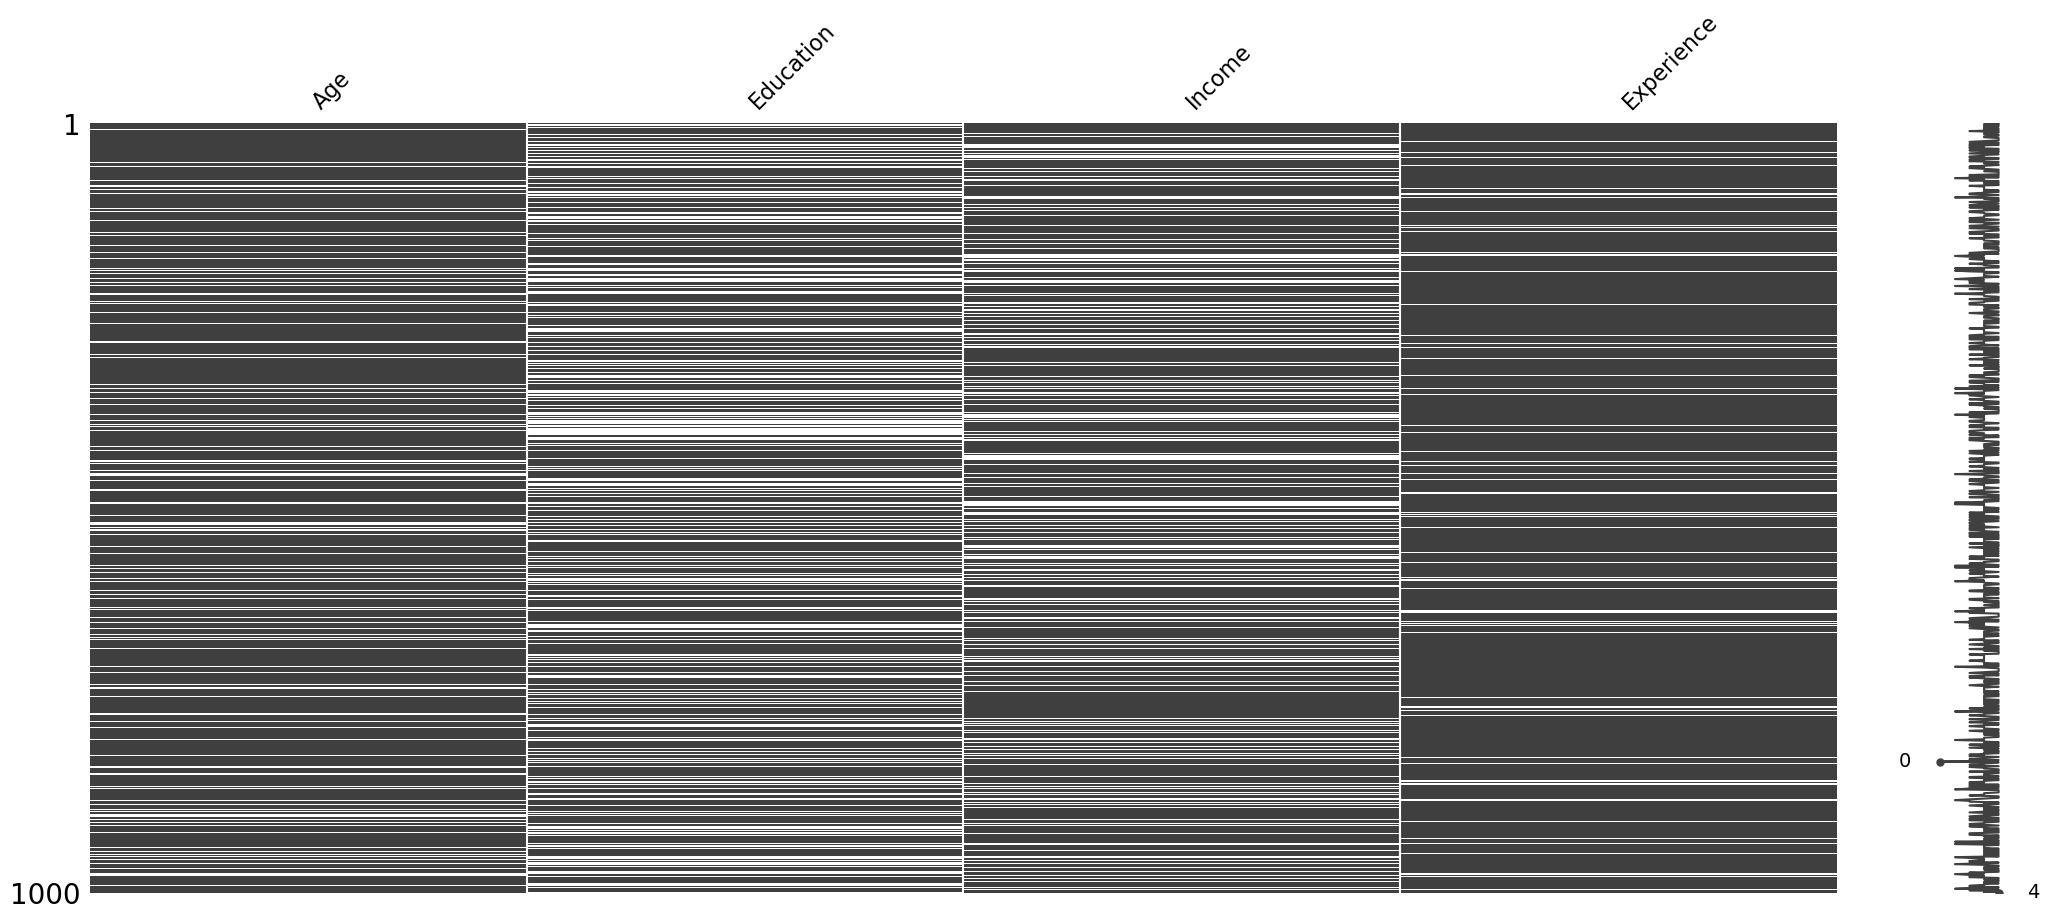

In [3]:
import missingno as msno
msno.matrix(data_missing)

In [4]:
from sklearn.impute import SimpleImputer
simpleimputer = SimpleImputer(missing_values = np.nan, strategy = 'mean')

from sklearn.impute import KNNImputer 
knnimputer = KNNImputer(missing_values = np.nan, n_neighbors = 5, weights = 'uniform')


In [5]:
data_simple = simpleimputer.fit_transform(X = data_missing)
data_knn = knnimputer.fit_transform(X=data_missing)

In [6]:
from sklearn.metrics import mean_absolute_error
mae_simple = mean_absolute_error(data_simple, data)
mae_knn = mean_absolute_error(data_knn, data)

In [7]:
print(mae_simple)
print(mae_knn)

59.006394999816884
49.46135874352925
